In [3]:
from typing import TypedDict

from IPython.display import Image
from langgraph.graph import END, START, StateGraph


In [4]:
class AgentState(TypedDict):
    num1: float
    num2: float
    op1: str

    num3: float
    num4: float
    op2: str

    result1: float
    result2: float


def adder_node(state: AgentState) -> AgentState:
    state["result1"] = state["num1"] + state["num2"]
    return state


def subtractor_node(state: AgentState) -> AgentState:
    state["result1"] = state["num1"] - state["num2"]
    return state


def adder_node2(state: AgentState) -> AgentState:
    state["result2"] = state["num3"] + state["num4"]
    return state


def subtractor_node2(state: AgentState) -> AgentState:
    state["result2"] = state["num3"] - state["num4"]
    return state


def router1_node(state: AgentState) -> str:
    if state["op1"] == "+":
        return "use_adder"
    elif state["op1"] == "-":
        return "use_subtract"

    raise ValueError(f"Invalid operator: {state['op1']}")


def router2_node(state: AgentState) -> str:
    if state["op2"] == "+":
        return "use_adder"
    elif state["op2"] == "-":
        return "use_subtract"

    raise ValueError(f"Invalid operator: {state['op2']}")


graph = StateGraph(AgentState)

graph.add_node("adder", adder_node)
graph.add_node("subtractor", subtractor_node)

graph.add_node("adder2", adder_node2)
graph.add_node("subtractor2", subtractor_node2)

graph.add_node("router1", lambda state: state)
graph.add_node("router2", lambda state: state)

# Edges
graph.add_edge(START, "router1")
graph.add_conditional_edges(
    "router1",
    router1_node,
    {
        "use_adder": "adder",
        "use_subtract": "subtractor",
    },
)

graph.add_edge("adder", "router2")
graph.add_edge("subtractor", "router2")
graph.add_conditional_edges(
    "router2",
    router2_node,
    {
        "use_adder": "adder2",
        "use_subtract": "subtractor2",
    },
)

graph.add_edge("adder2", END)
graph.add_edge("subtractor2", END)

app = graph.compile()

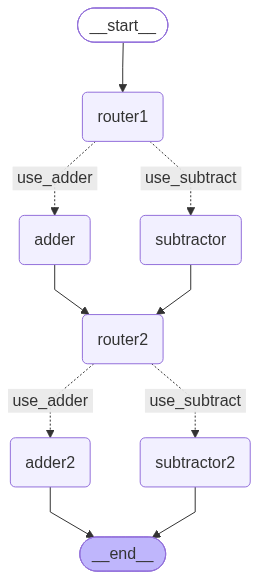

In [21]:
app

In [ ]:
result = app.invoke(AgentState(num1=5, num2=3, op1="+", num3=10, num4=4, op2="-", result1=0, result2=0))
result['result1'], result['result2']

(8, 6, 'lol')

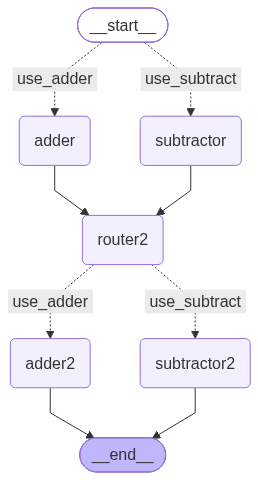

In [8]:
graph = StateGraph(AgentState)

graph.add_node("adder", adder_node)
graph.add_node("subtractor", subtractor_node)

graph.add_node("router2", router2_node)
graph.add_node("adder2", adder_node2)
graph.add_node("subtractor2", subtractor_node2)

# Edges
graph.add_conditional_edges(
    START,
    router1_node,
    {
        "use_adder": "adder",
        "use_subtract": "subtractor",
    },
)

graph.add_edge("adder", "router2")
graph.add_edge("subtractor", "router2")
graph.add_conditional_edges(
    "router2",
    router2_node,
    {
        "use_adder": "adder2",
        "use_subtract": "subtractor2",
    },
)

graph.add_edge("adder2", END)
graph.add_edge("subtractor2", END)

app = graph.compile()
app